# CortexMAE quickstart

- load a pretrained CortexMAE model from the [huggingface hub](https://huggingface.co/medarc/CortexMAE)
- run a masked reconstruction on an example fMRI scan from OpenNeuro
- visualize the predictions

### Colab setup

1. Activate the GPU runtime
2. Install the package
3. Restart the session

In [ ]:
!uv pip install "cortex_mae @ git+https://github.com/MedARC-AI/CortexMAE.git"

### Load the model

Load the default CortexMAE-F (flat map) model. The encoder is a ViT-B/16 with temporal patch size 4 trained with mask ratio 0.9.

In [1]:
import torch

from cortex_mae.inference import CortexMAE, resolve_file, list_models

In [2]:
model = CortexMAE.from_pretrained("cortex_mae_flat")
print(f"device: {model.get_device()}")

num_params = sum(p.numel() for p in model.model.parameters())
num_params_encoder = sum(p.numel() for p in model.model.encoder.parameters())
print(f"num params (total): {num_params / 1e6:.1f}M")
print(f"num params (encoder): {num_params_encoder / 1e6:.1f}M")

device: cuda:0
num params (total): 99.7M
num params (encoder): 86.2M


Get a preprocessed fsLR CIFTI time series from [OpenNeuro](https://openneuro.org/datasets/ds006072). (This will also cache the file.)

In [3]:
url = "s3://openneuro.org/ds006072/NON_BIDS/ciftis/sub-1_Drug2_rsfMRI_uout_bpss_sr_noGSR_sm4.dtseries.nii"
path = resolve_file(url, anon=True)
print(path)

/data/connor/.cache/cortex_mae/openneuro.org/ds006072/NON_BIDS/ciftis/sub-1_Drug2_rsfMRI_uout_bpss_sr_noGSR_sm4.dtseries.nii


### Run masked reconstruction

The outputs have shape `(clips, channels, frames, height, width)` where
- `clips` = number of non-overlapping sliding windows to cover the full input
- `channels` = image channels (always 1)
- `frames` = temporal frames, sampled at the model's internal TR = 1s.
- `height` = flat map image height (always 224)
- `width` = flat map image width (always 560)

In [4]:
torch.manual_seed(42)  # reproducible masking
recons = model.run_masked_recon(path)

print(f"mse loss:    {recons.loss.item():.3f}")
print(f"images:      {tuple(recons.images.shape)}")
print(f"pred_images: {tuple(recons.pred_images.shape)}")

mse loss:    0.828
images:      (164, 1, 16, 224, 560)
pred_images: (164, 1, 16, 224, 560)


Plot the masked reconstruction predictions. Each column is a temporal frame spaced 2 frames = 2 sec apart. Top is the masked input, middle is the model prediction (with pasted observed patches), and bottom is the target image.

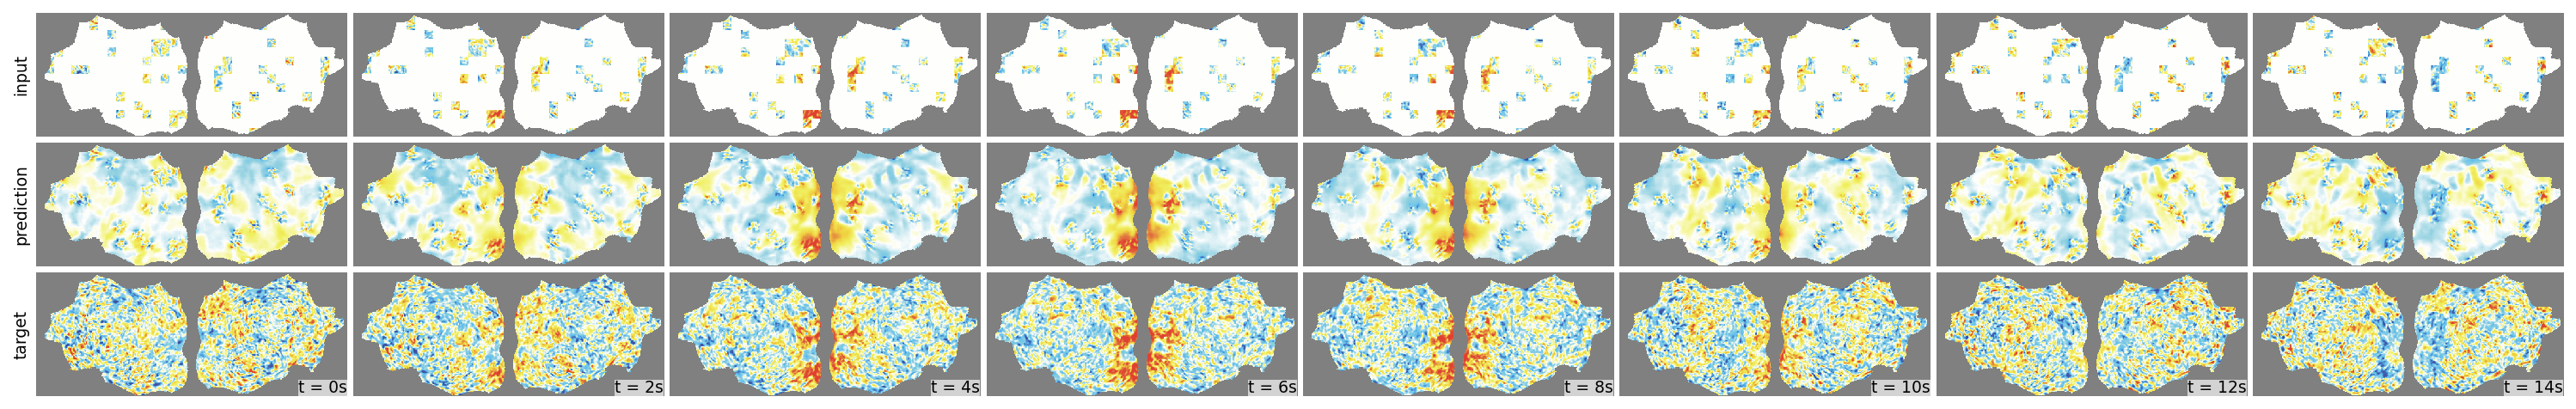

In [5]:
model.plot_masked_recon(recons, clip_idx=16);

### Compute model embeddings

Compute model embeddings for the entire input. For this we'll use the Schaefer-400 parcellation based model.

In [6]:
model = CortexMAE.from_pretrained("cortex_mae_parcel")

The outputs have shape `(clips, tokens, dim)` where
- `clips` = number of non-overlapping sliding windows to cover the full input
- `tokens` = ViT sequence length (4 temporal "patches" x 400 parcels)
- `dim` = ViT embedding dimension


In [7]:
embeds = model.run_embedding(path)

print(f"patch_embeds: {tuple(embeds.patch_embeds.shape)}")

patch_embeds: (164, 1600, 768)


Many more pretrained models available!

In [8]:
print("\n".join(list_models()))

cortex_mae_flat
cortex_mae_flat_r2
cortex_mae_flat_r3
cortex_mae_flat_r4
cortex_mae_flat_r5
cortex_mae_flat_r6
cortex_mae_flat_r7
cortex_mae_flat_r8
cortex_mae_volume
cortex_mae_volume_r2
cortex_mae_volume_r3
cortex_mae_volume_r4
cortex_mae_volume_r5
cortex_mae_volume_r6
cortex_mae_volume_r7
cortex_mae_volume_r8
cortex_mae_parcel
cortex_mae_parcel_r2
cortex_mae_parcel_r3
cortex_mae_parcel_r4
cortex_mae_parcel_r5
cortex_mae_parcel_r6
cortex_mae_parcel_r7
cortex_mae_parcel_r8
cortex_mae_flat_n100
cortex_mae_flat_n100_r2
cortex_mae_flat_n200
cortex_mae_flat_n200_r2
cortex_mae_flat_n400
cortex_mae_flat_n400_r2
cortex_mae_flat_n800
cortex_mae_flat_n800_r2
cortex_mae_flat_n1600
cortex_mae_flat_n1600_r2
cortex_mae_flat_d3
cortex_mae_flat_d3_r2
cortex_mae_flat_d6
cortex_mae_flat_d6_r2
cortex_mae_flat_d9
cortex_mae_flat_d9_r2
cortex_mae_flat_d12
cortex_mae_flat_d12_r2
cortex_mae_flat_d15
cortex_mae_flat_d15_r2
cortex_mae_flat_pt1
cortex_mae_flat_pt2
cortex_mae_flat_pt4
cortex_mae_flat_pt8
corte